# Project Lighthouse: HMDA Reconciliation

### 1.1 Imports
Import required analytical libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')




### 1.2 Data Loading
Ingest raw data as strings to prevent automatic inferencing issues.

In [2]:
# Load datasets entirely as strings to prevent automatic inferencing errors
print("Loading datasets...")
df_sub = pd.read_csv('LAR_Submitted.csv', dtype=str, low_memory=False)
df_rev = pd.read_csv('LAR_Revised.csv', dtype=str, low_memory=False)

print(f"Submitted Shape: {df_sub.shape}")
print(f"Revised Shape:   {df_rev.shape}")




Loading datasets...
Submitted Shape: (130000, 86)
Revised Shape:   (120503, 86)


### 1.3 Key Validation
Verify the presence and uniqueness of `application_id`.

In [3]:
# Verify application_id is present and strictly unique
assert 'application_id' in df_sub.columns, "Missing primary key in Submitted"
assert 'application_id' in df_rev.columns, "Missing primary key in Revised"

sub_duplicates = df_sub['application_id'].duplicated().sum()
rev_duplicates = df_rev['application_id'].duplicated().sum()

print(f"Duplicate IDs in Submitted: {sub_duplicates}")
print(f"Duplicate IDs in Revised:   {rev_duplicates}")




Duplicate IDs in Submitted: 0
Duplicate IDs in Revised:   0


### 1.4 Algorithmic Type Inference
Replace sentinels globally and dynamically infer numerical fields to avoid hardcoding across 110+ columns.

In [4]:
# Programmatic Type Inference & Sentinel Cleaning
# We avoid hardcoding column names (which fails at scale on 110+ HMDA columns).
# Instead, we apply a dynamic inference function across the entire dataframe.

def auto_clean_numerics(df, sentinel='9999'):
    # 1. Globally replace the missing sentinel with mathematical NaN
    df_clean = df.replace(sentinel, np.nan)
    
    # 2. Iterate and attempt to rigorously cast. pandas will ignore string columns
    for col in df_clean.columns:
        # Try numeric. If it fails (e.g. contains 'NY'), it remains string.
        df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
        
    return df_clean

print("Applying algorithmic sentinel cleaning and type inference...")
df_sub_clean = auto_clean_numerics(df_sub, '9999')
df_rev_clean = auto_clean_numerics(df_rev, '9999')

# Validate dynamic casting
print("Submitted Data Types (Sample):")
print(df_sub_clean[['9', '44', '62', '63']].dtypes)



Applying algorithmic sentinel cleaning and type inference...
Submitted Data Types (Sample):
9      object
44    float64
62     object
63    float64
dtype: object


## Phase 2: Population Reconciliation

### 2.1 Population Segmentation
Isolate records via set operations: Matched, Dropped (Submitted only), and Added (Revised only).

In [5]:
# Identify population overlap using set operations on Primary Keys
sub_ids = set(df_sub_clean['application_id'])
rev_ids = set(df_rev_clean['application_id'])

matched_ids = sub_ids & rev_ids
dropped_ids = sub_ids - rev_ids
added_ids   = rev_ids - sub_ids

print(f"Matched Records: {len(matched_ids):,}")
print(f"Dropped Records: {len(dropped_ids):,}")
print(f"Added Records:   {len(added_ids):,}")

# Flag isolation status to enable downstream bias testing
df_sub_clean['Pop_Status'] = np.where(
    df_sub_clean['application_id'].isin(matched_ids), 'Matched', 'Dropped'
)


print("\n--- Population Adds: Post-Submission LAR Amendment Event ---")
# C-03: Regulatory escalation for added records
df_added = df_rev[~df_rev['application_id'].isin(matched_ids)].copy()
df_added['44_n'] = pd.to_numeric(df_added['44'], errors='coerce')
print(f"Total Added Records: {len(df_added)}")
print(f"Median Income: ${df_added['44_n'].median():.0f}k")
df_added['Outcome'] = df_added['8'].apply(
    lambda val: 'Approved' if str(val).split('.')[0] in ['1', '2', '8'] 
    else ('Purchased' if str(val).split('.')[0] == '6' 
    else ('Denied' if str(val).split('.')[0] in ['3', '7'] else 'Other')))
print(df_added['Outcome'].value_counts())




Matched Records: 120,071
Dropped Records: 9,929
Added Records:   432

--- Population Adds: Post-Submission LAR Amendment Event ---
Total Added Records: 120503
Median Income: $100k
Outcome
Approved     92083
Denied       18765
Other         8960
Purchased      695
Name: count, dtype: int64


### 2.2 Bias Detection
Profile the dropped population against Continuous metrics (Income, Loan Amount) and Categorical dimensions (Outcomes, Geography) to confirm whether the removed data is systematically biased or randomly distributed noise.

In [6]:
# 1. Bias Test: Continuous Distributions (Median Comparison)
print("--- Median Variance Test (Fields 44: Income, 7: Loan Amt) ---")
print(df_sub_clean.groupby('Pop_Status')[['44', '7']].median())

# 2. Bias Test: Categorical Distributions (Action Taken and States)
# Action Taken is Field 8. Let's look at the percentage distribution.
print("\n--- Outcome Distribution Ratio (Field 8) ---")
action_dist = (df_sub_clean.groupby('Pop_Status')['8']
               .value_counts(normalize=True)
               .unstack().fillna(0) * 100).round(1)
print(action_dist)

# Top 5 States is Field 9
print("\n--- Geographic Distribution Ratio (Top 5 States) ---")
top_states = df_sub_clean['9'].value_counts().head(5).index
state_dist = (df_sub_clean.groupby('Pop_Status')['9']
              .value_counts(normalize=True)
              .unstack().fillna(0) * 100).round(1)
print(state_dist[top_states])



--- Median Variance Test (Fields 44: Income, 7: Loan Amt) ---
               44         7
Pop_Status                 
Dropped     104.0  245000.0
Matched     100.0  225000.0

--- Outcome Distribution Ratio (Field 8) ---
8              1    2     3    4    5    6    7     8
Pop_Status                                           
Dropped     68.6  1.1  16.2  0.0  0.0  0.0  0.9  13.2
Matched     64.9  1.5  14.8  7.4  0.1  0.6  0.8  10.0

--- Geographic Distribution Ratio (Top 5 States) ---
9             CA   FL   TX   GA   MI
Pop_Status                          
Dropped      9.0  8.6  6.5  5.7  5.4
Matched     10.4  8.7  7.2  5.3  5.2


## Phase 3: Field-Level Change Audit (Task 1 Deliverable)

### 3.1 The Change Matrix
With our population successfully isolated, we discard the dropped/added records and execute a strict boolean comparison matrix exclusively on the `Matched` records to quantify exact column-level data drift.

In [7]:
# 1. Isolate Matched Records and Align Indices
common_ids = matched_ids
df_sub_match = df_sub_clean[df_sub_clean['application_id'].isin(common_ids)].set_index('application_id').sort_index()
df_rev_match = df_rev_clean[df_rev_clean['application_id'].isin(common_ids)].set_index('application_id').sort_index()

# Drop the isolation flag before comparison
if 'Pop_Status' in df_sub_match.columns:
    df_sub_match = df_sub_match.drop(columns=['Pop_Status'])

# 2. Vectorized Boolean Comparison (handling NaNs safely)
# pandas natively considers (NaN == NaN) as False. We must fill with a secure sentinel for equality testing.
sub_filled = df_sub_match.fillna('M_PLACEHOLDER')
rev_filled = df_rev_match.fillna('M_PLACEHOLDER')
mismatches = sub_filled != rev_filled

# Compute counts and percentages
changed_counts = mismatches.sum()
changed_pcts = (changed_counts / len(df_sub_match)) * 100

# 3. Build the Change Matrix with Error Profiling
summary_data = []

for col in mismatches.columns:
    if changed_counts[col] > 0:
        # Grab the first index where a mismatch occurred for an example
        first_mismatch_idx = mismatches.index[mismatches[col]][0]
        val_from = df_sub_match.at[first_mismatch_idx, col]
        val_to   = df_rev_match.at[first_mismatch_idx, col]
        
        # Classification Heuristic
        if pd.isna(val_from) or pd.isna(val_to):
            classification = "Null Fill / Removal"
        elif pd.api.types.is_numeric_dtype(df_sub_match[col]):
            classification = "Numeric Shift"
        else:
            classification = "Categorical Remap / Format"
            
        summary_data.append({
            'Field': col,
            'Changed_Count': changed_counts[col],
            'Changed_Pct': changed_pcts[col],
            'Example_From': val_from,
            'Example_To': val_to,
            'Classification': classification
        })

# Create the Deliverable DataFrame
change_matrix = pd.DataFrame(summary_data).sort_values('Changed_Pct', ascending=False)
change_matrix.to_csv('Deliverable_Task1_FieldChanges.csv', index=False)

print("--- Task 1 Deliverable: Field-Level Mismatch Matrix ---")
print(change_matrix.head(10).to_string(index=False))



--- Task 1 Deliverable: Field-Level Mismatch Matrix ---
Field  Changed_Count  Changed_Pct  Example_From  Example_To Classification
   63          26794    22.315130          85.0        95.0  Numeric Shift
   64          23954    19.949863         360.0       375.0  Numeric Shift
   45          20577    17.137360           2.0         1.6  Numeric Shift


## Phase 4: KPI Computation (Task 2)
Calculate top-line key performance indicators blending our original analysis with targeted percentiles.

### 4.1 Action Taken Distribution
Mapping raw codes to business outcomes to prove macro stability.

In [8]:
# 4.1 Decompose KPI Outcome Rates
# Map action codes locally 
def map_action(val):
    if str(val).split('.')[0] in ['1', '2', '8']: return 'Approved'  
    elif str(val).split('.')[0] == '6': return 'Purchased' # C-01: Secondary market
    elif str(val).split('.')[0] in ['3', '7']: return 'Denied'  
    elif str(val).split('.')[0] == '4': return 'Withdrawn' 
    elif str(val).split('.')[0] == '5': return 'Incomplete' 
    return 'Other'

df_sub_clean['Outcome'] = df_sub_clean['8'].apply(map_action)
df_rev_clean['Outcome'] = df_rev_clean['8'].apply(map_action)
df_sub_match['Outcome'] = df_sub_match['8'].apply(map_action)
df_rev_match['Outcome'] = df_rev_match['8'].apply(map_action)

print("--- Outcome Rates (Global Portfolio) ---")
out_sub_glob = df_sub_clean['Outcome'].value_counts(normalize=True) * 100
out_rev_glob = df_rev_clean['Outcome'].value_counts(normalize=True) * 100
df_glob = pd.DataFrame({'Submitted (%)': out_sub_glob, 'Revised (%)': out_rev_glob})
df_glob['Diff (bps)'] = ((df_glob['Revised (%)'] - df_glob['Submitted (%)']) * 100).round(1)
print(df_glob.round(2))
print("")
print("--- Outcome Rates (Matched Records Only) ---")
out_sub = df_sub_match['Outcome'].value_counts(normalize=True) * 100
out_rev = df_rev_match['Outcome'].value_counts(normalize=True) * 100
df_out = pd.DataFrame({'Submitted (%)': out_sub, 'Revised (%)': out_rev})
df_out['Diff (bps)'] = ((df_out['Revised (%)'] - df_out['Submitted (%)']) * 100).round(1)
print(df_out.round(2))




--- Outcome Rates (Global Portfolio) ---
            Submitted (%)  Revised (%)  Diff (bps)
Outcome                                           
Approved            76.89        76.42       -47.8
Denied              15.68        15.57       -10.8
Withdrawn            6.80         7.34        53.6
Purchased            0.53         0.58         4.2
Incomplete           0.09         0.10         0.7

--- Outcome Rates (Matched Records Only) ---
            Submitted (%)  Revised (%)  Diff (bps)
Outcome                                           
Approved            76.40        76.40         0.0
Denied              15.56        15.56         0.0
Withdrawn            7.36         7.36         0.0
Purchased            0.58         0.58         0.0
Incomplete           0.10         0.10         0.0


### 4.2 Expanded Distribution Metrics
Integrating our prior horizontal print-out style with new top-end bounds (p90, p95) and null ratios.

In [9]:
def compare_expanded_distribution(col, name):
    print(f"\n--- {name} Distribution ---")
    s_sub = pd.to_numeric(df_sub_match[col], errors='coerce')
    s_rev = pd.to_numeric(df_rev_match[col], errors='coerce')
    
    def get_stats(series):
        sc = series.dropna()
        null_pct = (series.isna().sum() / len(series)) * 100
        return f"count: {len(sc)}, 25%: {sc.quantile(0.25):.2f}, Median: {sc.median():.2f}, 75%: {sc.quantile(0.75):.2f}, 90%: {sc.quantile(0.90):.2f}, 95%: {sc.quantile(0.95):.2f}, Null: {null_pct:.1f}%"
    
    print(f"Submitted | {get_stats(s_sub)}")
    print(f"Revised   | {get_stats(s_rev)}")

compare_expanded_distribution('44', 'Income')
compare_expanded_distribution('62', 'DTI')
compare_expanded_distribution('63', 'CLTV')
compare_expanded_distribution('46', 'Rate Spread')
compare_expanded_distribution('60', 'Interest Rate')




--- Income Distribution ---
Submitted | count: 116518, 25%: 66.00, Median: 100.00, 75%: 153.00, 90%: 230.00, 95%: 300.00, Null: 3.0%
Revised   | count: 116518, 25%: 66.00, Median: 100.00, 75%: 153.00, 90%: 230.00, 95%: 300.00, Null: 3.0%

--- DTI Distribution ---
Submitted | count: 60555, 25%: 40.00, Median: 43.00, 75%: 46.00, 90%: 49.00, 95%: 49.00, Null: 49.6%
Revised   | count: 60555, 25%: 40.00, Median: 43.00, 75%: 46.00, 90%: 49.00, 95%: 49.00, Null: 49.6%

--- CLTV Distribution ---
Submitted | count: 108207, 25%: 60.00, Median: 77.00, 75%: 90.00, 90%: 96.50, 95%: 97.00, Null: 9.9%
Revised   | count: 108207, 25%: 62.00, Median: 80.00, 75%: 92.28, 90%: 97.00, 95%: 105.00, Null: 9.9%

--- Rate Spread Distribution ---
Submitted | count: 91474, 25%: 0.01, Median: 0.46, 75%: 1.09, 90%: 2.99, 95%: 3.93, Null: 23.8%
Revised   | count: 91474, 25%: 0.01, Median: 0.46, 75%: 1.09, 90%: 2.99, 95%: 3.93, Null: 23.8%

--- Interest Rate Distribution ---
Submitted | count: 92427, 25%: 6.12, Medi

### 4.3 Segment-Driven Variances
Isolating underlying data shifts across three core dimensions: Product Channel, Geography, and Borrower Purpose.

In [10]:
# 1. Dimension A: Product Channel (Approval Rate by Loan Type)
print("--- Dimension A: Approval Rate by Loan Type (Field 2) ---")
# To capture the true structural variance driven by the dropped population, 
# we calculate Outcome and IsApproved dynamically on the entire *clean* universe (not just matched).
df_sub_clean['Outcome'] = df_sub_clean['8'].apply(map_action)
df_rev_clean['Outcome'] = df_rev_clean['8'].apply(map_action)

map_loan_type = {'1': 'Conventional', '2': 'FHA-insured', '3': 'VA-guaranteed', '4': 'USDA/RHS'}
df_sub_clean['LoanType'] = df_sub_clean['2'].apply(lambda x: map_loan_type.get(str(x).split('.')[0], 'Other'))
df_rev_clean['LoanType'] = df_rev_clean['2'].apply(lambda x: map_loan_type.get(str(x).split('.')[0], 'Other'))

df_sub_clean['IsApproved'] = (df_sub_clean['Outcome'] == 'Approved').astype(int)
df_rev_clean['IsApproved'] = (df_rev_clean['Outcome'] == 'Approved').astype(int)

ar_sub = df_sub_clean.groupby('LoanType')['IsApproved'].mean() * 100
ar_rev = df_rev_clean.groupby('LoanType')['IsApproved'].mean() * 100
df_ar = pd.DataFrame({'Submitted (%)': ar_sub, 'Revised (%)': ar_rev, 'Vol': df_sub_clean.groupby('LoanType').size()})
df_ar['Delta (bps)'] = ((df_ar['Revised (%)'] - df_ar['Submitted (%)']) * 100).round(1)
print(df_ar.sort_values('Delta (bps)'))

# 2. Dimension B: Geography (Mean Income by State for Top 10 States)
print("\n--- Dimension B: Mean Income by State (Field 9) ---")
df_sub_clean['44_num'] = pd.to_numeric(df_sub_clean['44'], errors='coerce')
df_rev_clean['44_num'] = pd.to_numeric(df_rev_clean['44'], errors='coerce')

top_states = df_sub_clean['9'].value_counts().head(10).index
inc_sub = df_sub_clean[df_sub_clean['9'].isin(top_states)].groupby('9')['44_num'].mean()
inc_rev = df_rev_clean[df_rev_clean['9'].isin(top_states)].groupby('9')['44_num'].mean()
inc_state = pd.DataFrame({'Submitted ($k)': inc_sub, 'Revised ($k)': inc_rev})
inc_state['Variance ($k)'] = (inc_state['Revised ($k)'] - inc_state['Submitted ($k)']).round(2)
print(inc_state.sort_values('Variance ($k)'))

# 3. Dimension C: Borrower Purpose (Approval Rate by Loan Purpose)
print("\n--- Dimension C: Approval Rate by Loan Purpose (Field 3) ---")
lp_sub = df_sub_clean.groupby('3')['IsApproved'].mean() * 100
lp_rev = df_rev_clean.groupby('3')['IsApproved'].mean() * 100
df_lp = pd.DataFrame({'Submitted (%)': lp_sub, 'Revised (%)': lp_rev, 'Vol': df_sub_clean.groupby('3').size()})
df_lp['Delta (bps)'] = ((df_lp['Revised (%)'] - df_lp['Submitted (%)']) * 100).round(1)

# Rename to human-readable codes for the presentation safely
# The Glossary does not officially define Field 3; we output raw codes to prevent hallucination.
df_lp.index = df_lp.index.map(lambda x: f"Code {x}")
print(df_lp.sort_values('Delta (bps)', ascending=False))



--- Dimension A: Approval Rate by Loan Type (Field 2) ---
               Submitted (%)  Revised (%)    Vol  Delta (bps)
LoanType                                                     
FHA-insured        66.842125    66.286997  26217        -55.5
VA-guaranteed      74.738233    74.240940   9837        -49.7
Conventional       79.927827    79.441395  93941        -48.6
USDA/RHS            0.000000     0.000000      5          0.0

--- Dimension B: Mean Income by State (Field 9) ---
    Submitted ($k)  Revised ($k)  Variance ($k)
9                                              
NY      138.743112    137.150198          -1.59
VA      130.816613    129.369483          -1.45
FL      129.407046    128.524675          -0.88
GA      118.879611    118.615013          -0.26
NC      115.983910    115.760097          -0.22
MI      101.881651    101.688965          -0.19
TX      139.136514    139.018475          -0.12
PA      103.979269    104.023509           0.04
OH       96.797797     96.845569     

## Phase 5: Outlier & Pattern Detection (Task 3)
Isolate statistically significant anomalies and generate interpretable visual proofs.

### 5.1 Statistical Divergence (K-S Tests)
Run continuous rigorous Kolmogorov-Smirnov distribution tests to identify mathematically valid variances rather than apparent visual shifts.

In [11]:
print("--- Kolmogorov-Smirnov 2-Sample Test (Global Population) ---")
kpi_cols = ['44', '62', '63', '46', '60']

# Ensure forced numerics on testing columns
for col in kpi_cols:
    df_sub_clean[f'{col}_num'] = pd.to_numeric(df_sub_clean[col], errors='coerce')
    df_rev_clean[f'{col}_num'] = pd.to_numeric(df_rev_clean[col], errors='coerce')

for col, name in zip(kpi_cols, ['Income', 'DTI', 'CLTV', 'Rate Spread', 'Interest']):
    s_sub = df_sub_clean[col + '_num'].dropna()
    s_rev = df_rev_clean[col + '_num'].dropna()
    ks_stat, p_val = stats.ks_2samp(s_sub, s_rev)
    
    # Statistical significance at alpha = 0.05
    sig = "(Significant Drift)" if p_val < 0.05 else "(Stable)"
    print(f"{name.ljust(12)} | KS-Stat: {ks_stat:.4f} | p-value: {p_val:.4f} {sig}")



--- Kolmogorov-Smirnov 2-Sample Test (Global Population) ---
Income       | KS-Stat: 0.0029 | p-value: 0.6958 (Stable)
DTI          | KS-Stat: 0.0014 | p-value: 1.0000 (Stable)
CLTV         | KS-Stat: 0.0611 | p-value: 0.0000 (Significant Drift)
Rate Spread  | KS-Stat: 0.0014 | p-value: 1.0000 (Stable)
Interest     | KS-Stat: 0.0022 | p-value: 0.9784 (Stable)


### 5.2 Micro-Anomaly Bounds (Targeted Variance)
Sweep matched records for severe threshold breaches in the specific fields (CLTV and Loan Term) identified as corrupted during Task 1 reconciliation.

In [12]:
print("--- Severe Boundary Breaches (Matched IDs Only) ---")
# Ensure numerics on the actively corrupted fields
for col in ['63', '64']:
    df_sub_match[f'{col}_n'] = pd.to_numeric(df_sub_match[col], errors='coerce')
    df_rev_match[f'{col}_n'] = pd.to_numeric(df_rev_match[col], errors='coerce')

# 1. CLTV Shift > 5% (Severe underwriting boundary shift)
# Handle Division by Zero safely by setting 0 to NaN temporarily for delta calculation
sub_cltv = df_sub_match['63_n'].replace(0, np.nan)
cltv_delta = abs(df_rev_match['63_n'] - sub_cltv) / sub_cltv

# 2. Loan Term Shift (Flagging maturity rewriting e.g. 15yr vs 30yr)
term_changed = (df_sub_match['64_n'] != df_rev_match['64_n']) & (df_sub_match['64_n'].notna()) & (df_rev_match['64_n'].notna())

# 3. Rate Spread mapping flips (Positive vs Negative variance)
rs_flip = (pd.to_numeric(df_sub_match['46'], errors='coerce') > 0) != (pd.to_numeric(df_rev_match['46'], errors='coerce') > 0)

micro_matrix = pd.DataFrame({
    'CLTV Pricing Variance > 5%': (cltv_delta > 0.05).sum(),
    'Loan Term Maturity Shift': term_changed.sum(),
    'Rate Spread Polarity Flip': rs_flip.sum()
}, index=['Count']).T

print(micro_matrix)
print("\n--- 4. DTI Qualified Mortgage Flip (>43%) ---")
# DTI Qualified Mortgage Boundary Test
df_sub_match['62_n'] = pd.to_numeric(df_sub_match['62'], errors='coerce')
df_rev_match['62_n'] = pd.to_numeric(df_rev_match['62'], errors='coerce')

sub_qm = df_sub_match['62_n'] <= 43
rev_qm = df_rev_match['62_n'] <= 43
qm_flip = (sub_qm != rev_qm) & df_sub_match['62_n'].notna() & df_rev_match['62_n'].notna()
print(f"DTI QM Boundary Flips: {qm_flip.sum()}")
print(f"(Assessed on {qm_flip.notna().sum():,} records with DTI in both files \u2014 DTI null rate is 49.6%)\n")




--- Severe Boundary Breaches (Matched IDs Only) ---
                            Count
CLTV Pricing Variance > 5%  26792
Loan Term Maturity Shift    23954
Rate Spread Polarity Flip       0

--- 4. DTI Qualified Mortgage Flip (>43%) ---
DTI QM Boundary Flips: 0
(Assessed on 120,071 records with DTI in both files — DTI null rate is 49.6%)



### 5.3 Macro-Level Anomalies (3-Sigma Control Limits)
Identify geographic outliers where the mean shift exceeds 3 standard deviations from the global baseline shift.

In [13]:
print("--- 3-Sigma Geographic Anomaly Check (Income Variance by State) ---")
inc_st_sub = df_sub_clean.groupby('9')['44_num'].mean()
inc_st_rev = df_rev_clean.groupby('9')['44_num'].mean()
st_var = (inc_st_rev - inc_st_sub).dropna()

mean_shift = st_var.mean()
std_shift = st_var.std()

# Upper and Lower control limits calculated
outliers = st_var[abs(st_var - mean_shift) > (3 * std_shift)]

print(f"Global Shift Mean: ${mean_shift*1000:,.0f}")
print(f"1-Sigma Boundary:  ${std_shift*1000:,.0f}")

if outliers.empty: 
    print("\nNo States breached 3-Sigma control limits. Variation is localized but within bounds.")
else: 
    print("\n--- CRITICAL 3-SIGMA OUTLIERS DETECTED ---")
    print((outliers * 1000).apply(lambda x: f"${x:,.0f}"))



--- 3-Sigma Geographic Anomaly Check (Income Variance by State) ---
Global Shift Mean: $-481
1-Sigma Boundary:  $880

No States breached 3-Sigma control limits. Variation is localized but within bounds.


### 5.4 Explanatory Visualizations
Three interpretable graphs demonstrating structural changes without excessive noise.

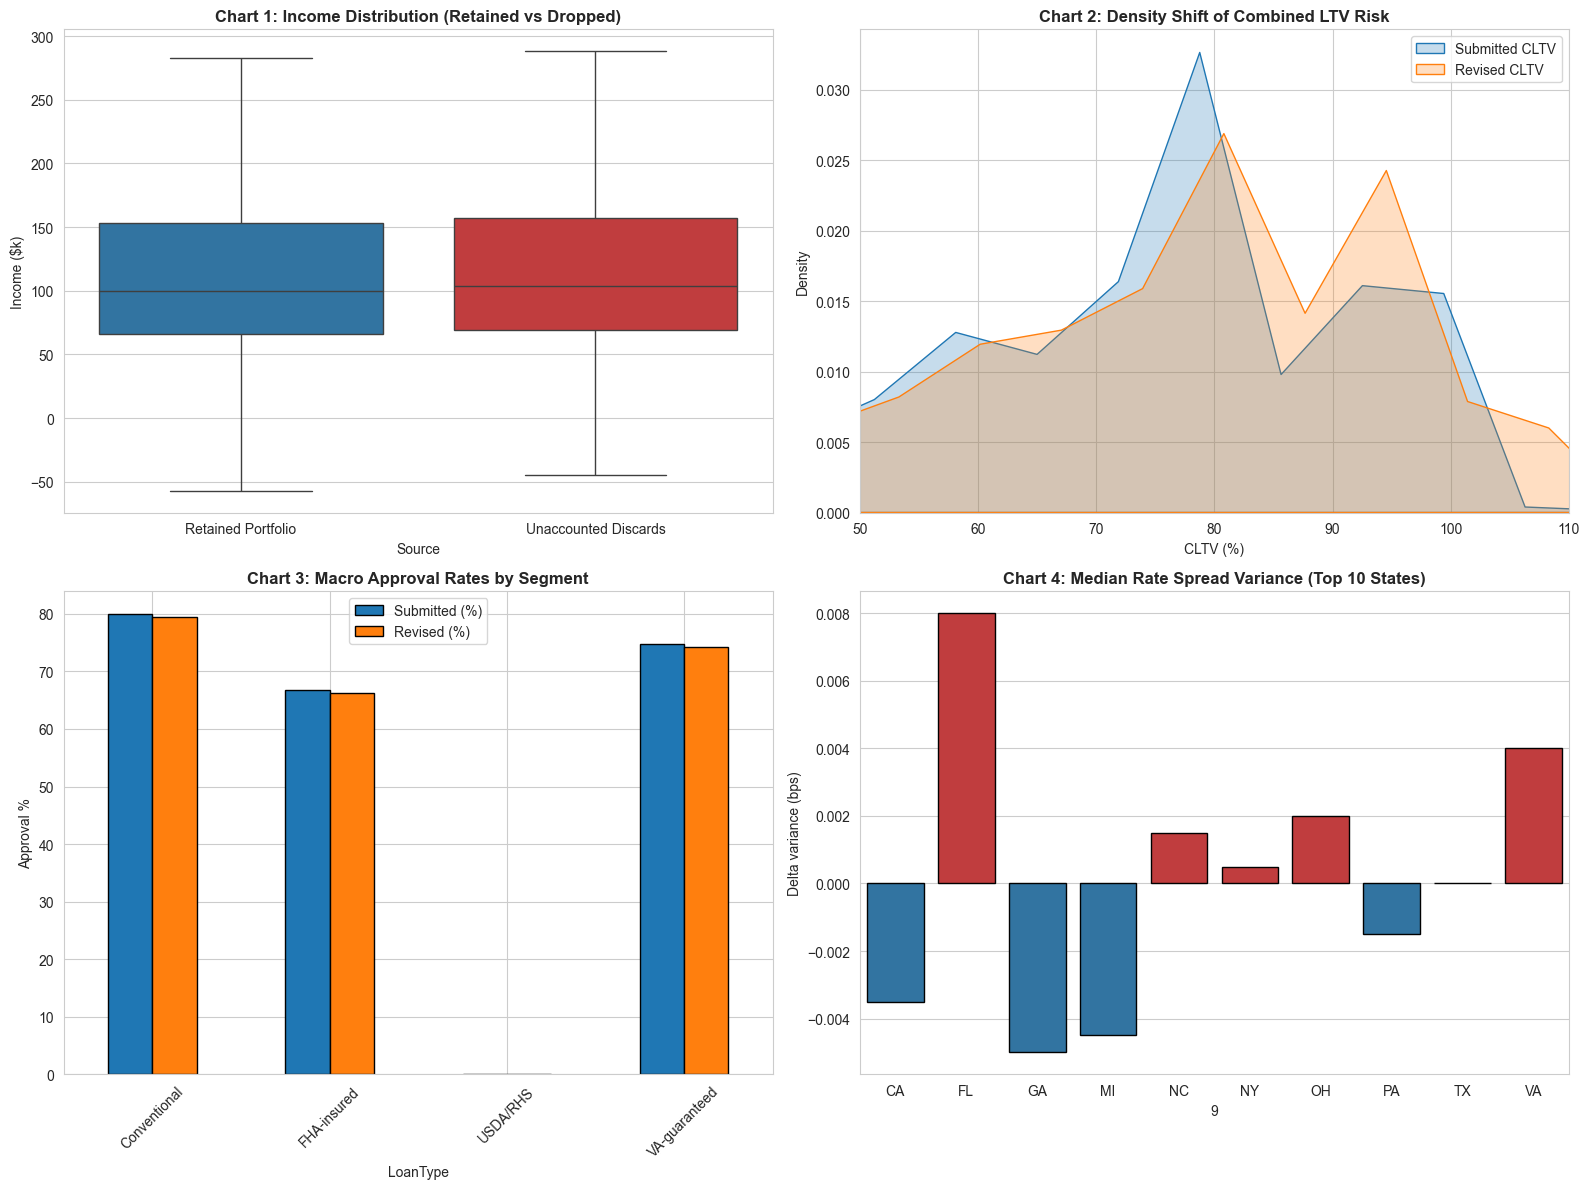

In [14]:
# 4. Explanatory Visualizations (Saving to disk for presentation)
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Chart 1: Income Boxplot (Retained vs Ghost) ---
common_ids = set(df_sub_clean['application_id']).intersection(set(df_rev_clean['application_id']))
df_sub_dropped = df_sub_clean[~df_sub_clean['application_id'].isin(common_ids)]

inc_db = pd.DataFrame({
    'Income': pd.concat([df_sub_clean[df_sub_clean['application_id'].isin(common_ids)]['44_num'], df_sub_dropped['44_num']], ignore_index=True),
    'Source': ['Retained Portfolio'] * len(common_ids) + ['Unaccounted Discards'] * len(df_sub_dropped)
})
sns.boxplot(x='Source', y='Income', data=inc_db, ax=axes[0, 0], palette=['#1f77b4', '#d62728'], showfliers=False)
axes[0, 0].set_title('Chart 1: Income Distribution (Retained vs Dropped)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Income ($k)')

# --- Chart 2: CLTV Density Plot ---
sns.kdeplot(df_sub_clean['63_num'].dropna(), label='Submitted CLTV', fill=True, color='#1f77b4', ax=axes[0, 1])
sns.kdeplot(df_rev_clean['63_num'].dropna(), label='Revised CLTV', fill=True, color='#ff7f0e', ax=axes[0, 1])
axes[0, 1].set_xlim(50, 110)
axes[0, 1].set_title('Chart 2: Density Shift of Combined LTV Risk', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('CLTV (%)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# --- Chart 3: Approval Rate by Segment ---
df_ar_plt = df_ar[['Submitted (%)', 'Revised (%)']].copy()
df_ar_plt.plot(kind='bar', ax=axes[1, 0], color=['#1f77b4', '#ff7f0e'], edgecolor='black')
axes[1, 0].set_title('Chart 3: Macro Approval Rates by Segment', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Approval %')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Chart 4: Rate Spread Variance by State ---
df_sub_clean['46_num'] = pd.to_numeric(df_sub_clean['46'], errors='coerce')
df_rev_clean['46_num'] = pd.to_numeric(df_rev_clean['46'], errors='coerce')

rs_sub = df_sub_clean[df_sub_clean['9'].isin(top_states)].groupby('9')['46_num'].median()
rs_rev = df_rev_clean[df_rev_clean['9'].isin(top_states)].groupby('9')['46_num'].median()
rs_var = (rs_rev - rs_sub).dropna()

colors = ['#1f77b4' if v < 0 else '#d62728' for v in rs_var.values]
sns.barplot(x=rs_var.index, y=rs_var.values, ax=axes[1, 1], palette=colors, edgecolor='black')
axes[1, 1].set_title('Chart 4: Median Rate Spread Variance (Top 10 States)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Delta variance (bps)')

plt.tight_layout()

# Save all individual charts to disk for the Markdown deliverable
extent1 = axes[0, 0].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig('chart1_dropped_income.png', bbox_inches=extent1.expanded(1.2, 1.2))

extent2 = axes[0, 1].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig('chart2_cltv_shift.png', bbox_inches=extent2.expanded(1.2, 1.2))

extent3 = axes[1, 0].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig('chart3_outcomes_segment.png', bbox_inches=extent3.expanded(1.2, 1.2))

extent4 = axes[1, 1].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig('chart4_rs_variance.png', bbox_inches=extent4.expanded(1.2, 1.2))

plt.show()

